In [3]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
from os import PathLike
import shutil
import tempfile
import numpy as np
import polars as pl
from typing import Literal
from collections.abc import Callable
from bs4 import BeautifulSoup
import fsspec
import httpx
from datetime import date
import re
from loguru import logger
from jsna_climate_and_environment.geography.places import read_gdb
from jsna_climate_and_environment.nhs_orgs.practice_registrations import get_surrey_health_lookup

<Axes: >

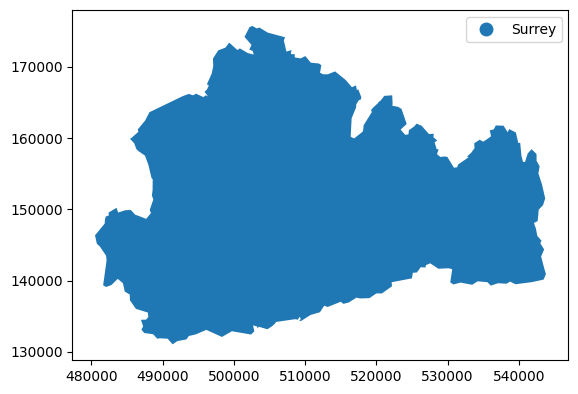

In [4]:
surrey_county = read_gdb("county")
surrey_county.plot(column="county_name", legend=True)

In [5]:
surrey_county

,county_code,county_name,source_url,geometry
0,E10000030,Surrey,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((502587.903 175761.398, 503199...."


<Axes: >

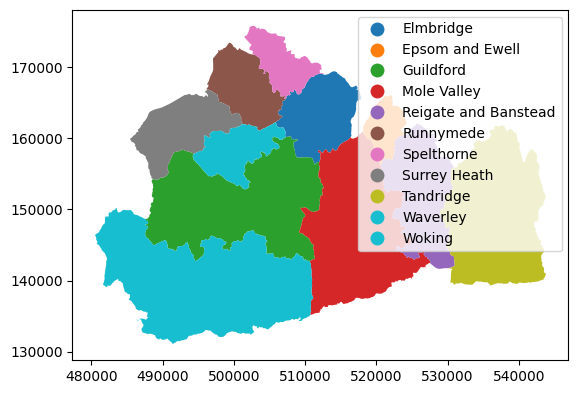

In [6]:
surrey_districts =  read_gdb("districts")
surrey_districts.plot(column="district_name", legend=True)

In [7]:
surrey_districts

,district_code,district_name,source_url,geometry
0,E07000207,Elmbridge,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((514102.898 169389.002, 514126...."
1,E07000208,Epsom and Ewell,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((522153.95 166034.05, 522160.35..."
2,E07000209,Guildford,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((505811.301 160132.902, 505820 ..."
3,E07000210,Mole Valley,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((518097.399 160868.801, 518106...."
4,E07000211,Reigate and Banstead,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((525705.397 162028.299, 525703...."
5,E07000212,Runnymede,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((499990.701 172802.295, 500000...."
6,E07000213,Spelthorne,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((503199.299 175411.098, 503325...."
7,E07000214,Surrey Heath,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((496870.6 166574.9, 496879.5 16..."
8,E07000215,Tandridge,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((537677 161787.3, 537679.7 1617..."
9,E07000216,Waverley,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((483734.4 149584.101, 483745.10..."


<Axes: >

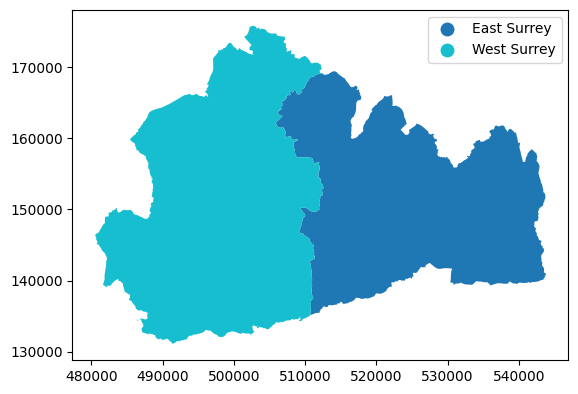

In [8]:
surrey_lgr =  read_gdb("lgr")
surrey_lgr.plot(column="lgr_name", legend=True)

In [9]:
surrey_lgr

,lgr_name,lgr_code,source_url,geometry
0,East Surrey,SCC_EAST,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((527526.302 142467.199, 527521...."
1,West Surrey,SCC_WEST,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((483853.401 149576.104, 483891...."


<Axes: >

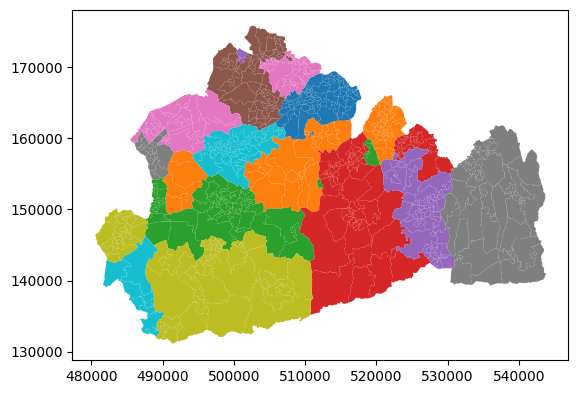

In [11]:
surrey_lsoas = read_gdb("lsoa")
surrey_lsoas.plot(column="lsoa21_name")

In [12]:
surrey_lsoas

,lsoa21_code,lsoa21_name,source_url,geometry
0,E01030296,Elmbridge 015A,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((517080.666 164767.597, 517080...."
1,E01030297,Elmbridge 015B,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((515036 164690.752, 515038.813 ..."
2,E01030298,Elmbridge 015C,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((516150.144 164498.2, 516200.87..."
3,E01030299,Elmbridge 015D,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((515282.144 163601.63, 515307.6..."
4,E01030300,Elmbridge 017A,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((511271.573 160957.78, 511265.0..."
...,...,...,...,...
716,E01035360,Reigate and Banstead 016G,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((527848.04 144674.199, 527859 1..."
717,E01035361,Reigate and Banstead 018F,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((528530.714 143218.357, 528543...."
718,E01035362,Reigate and Banstead 018G,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((528763 143199.817, 528761.044 ..."
719,E01035363,Tandridge 002E,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((533975.062 158553, 533976.895 ..."


In [ ]:
def stream_file(response: httpx.Response, download_location: Path):
    response.raise_for_status()
    download_location.parent.mkdir(exist_ok=True, parents=True)
    with download_location.open("wb") as file:
        for chunk in response.iter_bytes():
            file.write(chunk)

<Axes: >

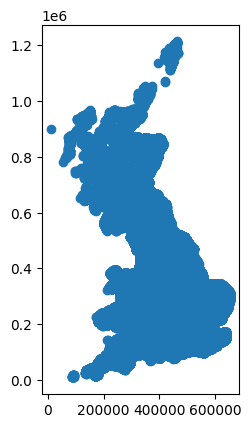

In [ ]:
def read_os_dataset(dataset_name, gpkg_filename: str, layer:int=0):
    root_dir = Path("data/os")
    root_dir.mkdir(exist_ok=True,parents=True)
    file_dir = root_dir / f"{dataset_name}.zip"
    if not file_dir.exists():
        # logger.info("downloading file...")
        with httpx.stream(
            "GET", 
            f"https://api.os.uk/downloads/v1/products/{dataset_name}/downloads?area=GB&format=GeoPackage&redirect",
            follow_redirects=True
        ) as response:
            stream_file(response, file_dir)
    
    return gpd.read_file(
        filename=f"{file_dir.as_posix()}!{gpkg_filename}", layer=layer  
    )
greenspace_access = read_os_dataset("OpenGreenspace", "Data/opgrsp_gb.gpkg", 0)
greenspace_access.plot()

In [ ]:
greenspace_polygons = read_os_dataset("OpenGreenspace", "Data/opgrsp_gb.gpkg", 1)
greenspace_polygons

,id,function,distinctive_name_1,distinctive_name_2,distinctive_name_3,distinctive_name_4,geometry
0,0D627D81-9D1C-45B3-9670-E9E46D4320BB,Public Park Or Garden,Herne Bay Crematorium and Memorial Gardens,None,None,None,"MULTIPOLYGON (((616860.92 165983.07, 616860.15..."
1,1C4FD10E-2BBE-4535-ACF6-2316358DF47A,Other Sports Facility,Grove View Health and Care Hub and Apartments,None,None,None,"MULTIPOLYGON (((501789.27 222495.56, 501794.64..."
2,3585B3AA-E7EE-4E02-A9EA-C5E68C27B534,Public Park Or Garden,Arun Crematorium and Memorial Gardens,None,None,None,"MULTIPOLYGON (((497925.39 101657.73, 497923.95..."
3,3B3400A5-C4D3-48B9-AC3D-58582A92A0FE,Public Park Or Garden,Bishopbriggs Crematorium and Memorial Gardens,None,None,None,"MULTIPOLYGON (((263178.95 672492.24, 263185.7 ..."
4,3D6C4ACB-1515-80C3-E063-8ECAA00A8EB3,Allotments Or Community Growing Spaces,None,None,None,None,"MULTIPOLYGON (((303816.17 169712.3, 303805.48 ..."
...,...,...,...,...,...,...,...
165582,BC7FE2E5-6E33-4DF9-A168-0E22CDF9FF73,Public Park Or Garden,Holytown Crematorium and Memorial Gardens,None,None,None,"MULTIPOLYGON (((277117.72 660499.33, 277118.19..."
165583,C5BC4AB1-B446-4141-A792-C059EC405588,Other Sports Facility,Danderhall Library and Leisure Centre,None,None,None,"MULTIPOLYGON (((330716.49 669814.53, 330667.22..."
165584,C7ACADF0-01AC-47B2-BD30-E0C3223F2E57,Public Park Or Garden,Northumberland Woodland Burial and Crematorium,None,None,None,"MULTIPOLYGON (((417739.82 597699.1, 417742.13 ..."
165585,DF2DE585-11D8-40B9-B274-2BF8584C5994,Public Park Or Garden,None,None,None,None,"MULTIPOLYGON (((536108.39 174727.68, 536100.05..."


<Axes: >

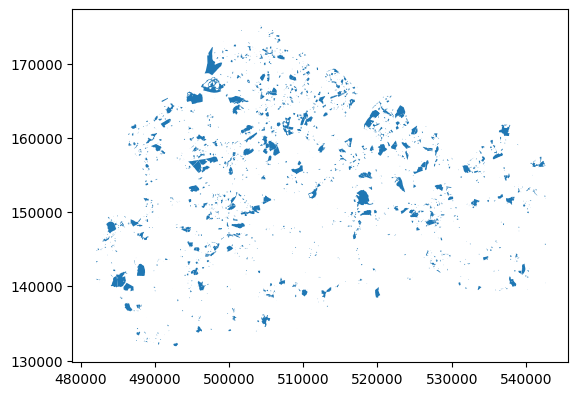

In [ ]:
surrey_greenspace = greenspace_polygons.clip(surrey_county.geometry)
surrey_greenspace.plot()

In [ ]:
from matplotlib.colors import Normalize, LinearSegmentedColormap

<Axes: >

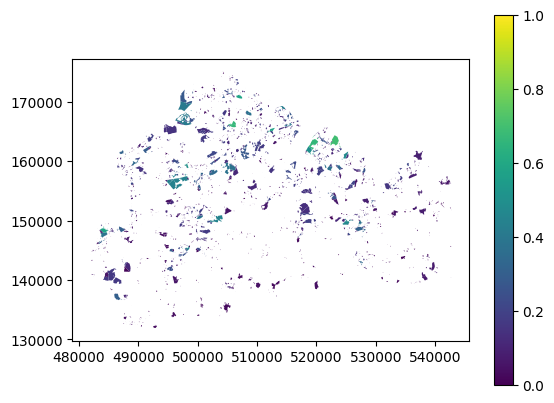

In [ ]:
greenspace_in_lsoa = surrey_lsoas.geometry.intersection(surrey_greenspace.geometry.union_all())
greenspace_by_lsoa = surrey_lsoas[["LSOA21CD", "geometry"]].copy()
greenspace_by_lsoa["geometry"] = greenspace_in_lsoa
greenspace_by_lsoa["greenspace_density"] = greenspace_in_lsoa.area / surrey_lsoas.geometry.area
greenspace_by_lsoa = greenspace_by_lsoa.explode()
greenspace_by_lsoa = greenspace_by_lsoa[~greenspace_by_lsoa.is_empty & (greenspace_by_lsoa.geom_type != "Point")]
fig, ax = plt.subplots(1, 1)
greenspace_by_lsoa.plot(
    column="greenspace_density",
    legend=True,
    ax=ax,
    norm=Normalize(0,1),
    # cmap=LinearSegmentedColormap.from_list("", ["linen", "yellowgreen", "green", "darkgreen"])
)

In [ ]:
deprivation_df = imd_25.unpivot(
    index=["LSOA21CD", "population"], 
    variable_name="Domain of Deprivation", 
    value_name="decile"
).with_columns(
    CTY24CD=pl.lit(SURREY_COUNTY_CODE)
).to_pandas()

gdb_lookup_file = write_tableau_gdb(
    output_path="I:/PHE/JSNA/_JSNA 2021/5. JSNA Chapters/Climate and Environment/data/lookups.gdb",
    lsoa=surrey_lsoas,
    lgr=surrey_lgr,
    districts=surrey_districts,
    county=surrey_county
)
deprivation_file = write_tableau_indicators(
    "I:/PHE/JSNA/_JSNA 2021/5. JSNA Chapters/Climate and Environment/data/deprivation.csv",
    deprivation_df,
    lsoa="LSOA21CD",
    lgr="lgr_name",
    districts="LAD25CD",
    county="CTY24CD"
)
gbd_map_base = write_tableau_gdb(
    output_path="I:/PHE/JSNA/_JSNA 2021/5. JSNA Chapters/Climate and Environment/data/maps.gdb",
    greenspace=greenspace_by_lsoa,
)

In [ ]:
generic_code_joiner = 

In [ ]:
import polars as pl
from polars import selectors as cs
climate_projection_datasets = {
    "d490e26725f141a4972164b95e315633": "Winter Minimum Temperature Change",
}
climate_projection_dfs: list[pl.DataFrame] = []
dummy_scenario_dates = {
    "1981-2000": 1990,
    "2001-2020": 2010,
    "1.5°C": 2030,
    "2°C": 2040,
    "2.5°C": 2050,
    "3°C": 2060,
    "3.5°C": 2070,
    "4°C": 2080
}

for id, name in climate_projection_datasets.items():
    df = (
        pl.read_csv(f"https://hub.arcgis.com/api/download/v1/items/{id}/csv?layers=0")
        .filter(pl.col("CODE").is_in(SURREY_DISTRICTS))
        .unpivot(on=cs.ends_with("lower", "median", "upper"), index="CODE")
        .with_columns(
            measure=pl.col("variable").str.split(" ").list.last(),
            scenario=pl.col("variable").str.split(" ").list.get(-2),
        ).pivot(on="measure", index=["CODE", "scenario"], values=["value"])
        .with_columns(
            indicator=pl.lit(name), 
            LAD25CD="CODE", 
            CTY24CD=pl.lit(SURREY_COUNTY_CODE),
            dummy_dates=pl.date(pl.col("scenario").replace_strict(dummy_scenario_dates), 1, 1)
        )
    )
    climate_projection_dfs.append(df)

In [ ]:
write_tableau_indicators(
    "I:/PHE/JSNA/_JSNA 2021/5. JSNA Chapters/Climate and Environment/data/projections.csv", 
    pl.concat(climate_projection_dfs).to_pandas(),
        lsoa="LSOA21CD",
    lgr="lgr_name",
    districts="LAD25CD",
    county="CTY24CD"
)

WindowsPath('I:/PHE/JSNA/_JSNA 2021/5. JSNA Chapters/Climate and Environment/data/projections.csv')

In [ ]:
climate_projection_dfs[0].select(pl.col("scenario").replace_strict({
    "1981-2000": 1990,
    "2001-2020": 2010,
    "1.5°C": 2030,
    "2°C": 2040,
    "2.5°C": 2050,
    "3°C": 2060,
    "3.5°C": 2070,
    "4°C": 2080
}))

scenario
str
"""1.5°C"""
"""1981-2000"""
"""2.5°C"""
"""2001-2020"""
"""2°C"""
"""3.5°C"""
"""3°C"""
"""4°C"""


In [ ]:
example_df

,month,min_temperature,max_temperature,CTY24CD,scenario
0,1,0,10,E10000030,2 degrees
1,2,2,12,E10000030,2 degrees
2,3,3,13,E10000030,2 degrees
3,4,8,18,E10000030,2 degrees
4,5,12,22,E10000030,2 degrees
5,6,22,32,E10000030,2 degrees
6,7,32,42,E10000030,2 degrees
7,8,31,41,E10000030,2 degrees
8,9,28,38,E10000030,2 degrees
9,10,22,32,E10000030,2 degrees


In [ ]:
deprivation_df

,LSOA21CD,population,Domain of Deprivation,decile,lgr_name,LAD25CD,CTY24CD
0,E01030296,1768,Index of Multiple Deprivation,10,NaN,NaN,NaN
1,E01030297,2150,Index of Multiple Deprivation,10,NaN,NaN,NaN
2,E01030298,1636,Index of Multiple Deprivation,8,NaN,NaN,NaN
3,E01030299,1690,Index of Multiple Deprivation,9,NaN,NaN,NaN
4,E01030300,1633,Index of Multiple Deprivation,6,NaN,NaN,NaN
...,...,...,...,...,...,...,...
7185,E01035360,2061,Income Deprivation Affecting Older People,10,NaN,NaN,NaN
7186,E01035361,1443,Income Deprivation Affecting Older People,8,NaN,NaN,NaN
7187,E01035362,1306,Income Deprivation Affecting Older People,6,NaN,NaN,NaN
7188,E01035363,1435,Income Deprivation Affecting Older People,4,NaN,NaN,NaN


In [ ]:
bua_extents = read_os_dataset("BuiltUpAreas", "os_open_built_up_areas.gpkg", 1)
bua_extents

d:\nmolkent\code\scc_jsna\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: unable to open database file: this file is a WAL-enabled database. It cannot be opened because it is presumably read-only or in a read-only directory. Retrying with IMMUTABLE=YES open option
  return ogr_read(


,relatedtogsscode,name1_text,name1_language,name2_text,name2_language,areahectares,geometry_area_m,geometry
0,S45000832,A'Choingheal,gla,Connel,eng,37.31,373125.0,"MULTIPOLYGON (((191450 733950, 191450 733925, ..."
1,S45000833,A'Chorpaich,gla,Corpach,eng,109.00,1090000.0,"MULTIPOLYGON (((208425 776375, 208400 776375, ..."
2,E63010387,Abberley,None,None,None,48.25,482500.0,"MULTIPOLYGON (((374450 266700, 374450 266725, ..."
3,E63007254,Abbeytown,None,None,None,30.06,300625.0,"MULTIPOLYGON (((317275 550175, 317250 550175, ..."
4,E63009334,Abbots Bromley,None,None,None,68.38,683750.0,"MULTIPOLYGON (((407625 324200, 407625 324225, ..."
...,...,...,...,...,...,...,...,...
8580,W45000877,Ystrad Aeron,None,None,None,24.50,245000.0,"MULTIPOLYGON (((252225 255800, 252225 255825, ..."
8581,W45001125,Ystrad Mynach,None,None,None,358.81,3588125.0,"MULTIPOLYGON (((313500 194675, 313500 194700, ..."
8582,W45000983,Ystradgynlais,None,None,None,144.69,1446875.0,"MULTIPOLYGON (((279150 209375, 279150 209400, ..."
8583,W45001216,Ystradowen,None,None,None,20.44,204375.0,"MULTIPOLYGON (((301275 177900, 301300 177900, ..."


In [ ]:
surrey_bua = bua_extents.clip(surrey_county.geometry)
bua_in_lsoa = surrey_lsoas.geometry.intersection(surrey_bua.geometry.union_all())
surrey_lsoas["bua_density"] = bua_in_lsoa.area / surrey_lsoas.geometry.area
surrey_lsoas

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry,greenspace_density,bua_density
0,E01030296,Elmbridge 015A,None,516581,163688,51.3603,-0.32694,118e64dd-0a3a-444c-b24b-569c97dc32e6,"POLYGON ((517080.666 164767.597, 517080.595 16...",0.015399,0.372239
1,E01030297,Elmbridge 015B,None,515152,163746,51.3611,-0.34744,2bf1c1e4-13a6-4b45-93bb-9b0de0f29fd4,"POLYGON ((515036 164690.752, 515038.813 164678...",0.017301,0.466894
2,E01030298,Elmbridge 015C,None,515852,163861,51.3620,-0.33735,16285d9e-cace-4fc2-bee5-81237ab33c85,"POLYGON ((516150.144 164498.2, 516200.877 1644...",0.194970,0.572184
3,E01030299,Elmbridge 015D,None,515509,162922,51.3536,-0.34258,506e748d-7284-4033-b375-f11bd506a724,"POLYGON ((515282.144 163601.63, 515307.698 163...",0.011467,0.378305
4,E01030300,Elmbridge 017A,None,511067,160568,51.3334,-0.40708,7e0f09b0-c738-400c-b67c-8fcdb6bf7dbf,"POLYGON ((511271.573 160957.78, 511265.097 160...",0.014810,0.959958
...,...,...,...,...,...,...,...,...,...,...,...
714,E01035360,Reigate and Banstead 016G,None,527362,144268,51.1835,-0.17909,6bb14c62-940f-462f-93d8-327d6b0cd511,"POLYGON ((527848.04 144674.199, 527859 144608,...",0.009375,0.875760
715,E01035361,Reigate and Banstead 018F,None,528255,143409,51.1755,-0.16662,98c8e452-95c0-4386-809a-67cdfd787056,"POLYGON ((528530.714 143218.357, 528543.734 14...",0.000505,0.989734
716,E01035362,Reigate and Banstead 018G,None,528354,143035,51.1722,-0.16534,df4a442a-1ed5-4384-870b-b0c9edded1fb,"POLYGON ((528763 143199.817, 528761.044 143197...",0.000000,0.967007
717,E01035363,Tandridge 002E,None,533797,158989,51.3143,-0.08157,46ae2f90-07fd-4ffe-adc9-81254d791bee,"POLYGON ((533975.062 158553, 533976.895 158540...",0.001164,0.750781


<Axes: >

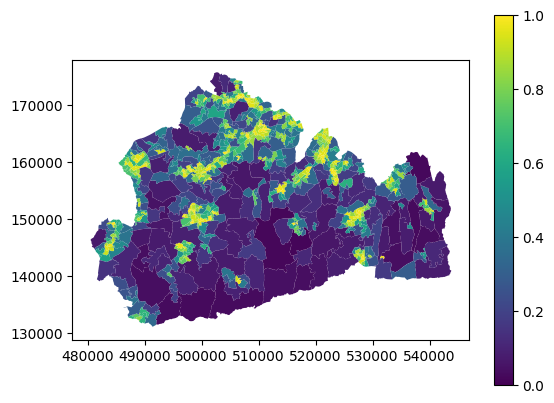

In [ ]:
fig, ax = plt.subplots(1, 1)
surrey_lsoas.plot(
    column="bua_density",
    legend=True,
    ax=ax,
    norm=Normalize(0,1),
)

In [ ]:
roads = read_os_dataset("OpenRoads", "Data/oproad_gb.gpkg", 1)
roads

,id,fictitious,road_classification,road_function,form_of_way,road_classification_number,name_1,name_1_lang,name_2,name_2_lang,...,length,length_uom,loop,primary_route,trunk_road,start_node,end_node,road_number_toid,road_name_toid,geometry
0,00000654-4C3D-430B-A4D1-F35861E7C681,False,Unclassified,Local Road,Single Carriageway,None,Coombe Street,None,None,None,...,68.0,m,False,False,False,AFD6D1D6-00B0-4E61-82F4-60CFECE24218,7171C93E-40C0-410E-8359-33A9441CADE6,None,osgb4000000019412005,"LINESTRING (435582 278630, 435614.5 278620.5, ..."
1,000006FD-D898-454A-AB2D-F6E79835585F,False,Unknown,Restricted Local Access Road,Single Carriageway,None,None,None,None,None,...,1143.0,m,False,False,False,F52B454A-EFA1-41FA-8C5F-C2C63616290E,867F9211-2832-471C-8D2A-00527587A670,None,None,"LINESTRING (131986.39 643294.32, 132201.33 643..."
2,0000082E-4729-4888-8926-8BE4864EAA50,False,Unclassified,Minor Road,Single Carriageway,None,Bannacle Hill Road,None,None,None,...,30.0,m,False,False,False,C056EF56-AAF1-4CB5-8D3F-5EF2BE8179AD,0B3885CD-B595-4186-BDDA-4E7806FC42C9,None,osgb4000000023667477,"LINESTRING (493982.37 138183.47, 493990.27 138..."
3,00000B00-8795-4F8C-AFC9-27B5278A43EC,False,B Road,B Road,Single Carriageway,B212,Lee Road,None,None,None,...,5.0,m,False,False,False,D68CBAFE-B209-4D26-B973-4E17780D049D,F83FEEFC-4919-436A-95A9-172B1D97BF61,osgb4000000030576316,osgb4000000030570475,"LINESTRING (539650.09 175876.7, 539650.32 1758..."
4,00000D6E-87CD-47F8-8270-5D57697863E7,False,Unclassified,Local Road,Single Carriageway,None,Erica Road,None,None,None,...,131.0,m,False,False,False,854A2665-18DC-461C-B979-3AFB65258E9A,49DD7DC1-220B-4CCE-9D74-257FCF4DB130,None,osgb4000000019399142,"LINESTRING (482226 239739, 482284.5 239769, 48..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3941294,FFFFF7E0-2BDA-478E-80A3-BD11F23C7B08,False,Classified Unnumbered,Minor Road,Single Carriageway,None,None,None,None,None,...,25.0,m,False,False,False,8009AEAE-8993-4469-97EB-4AE1154B8505,22FFD143-1AE7-45E7-B417-AB44A17AB271,None,None,"LINESTRING (482568.33 331347.46, 482580.93 331..."
3941295,FFFFF88D-6AAB-4F18-8976-F75FB8E12D0C,False,Unclassified,Local Access Road,Shared Use Carriageway,None,York Street,None,None,None,...,37.0,m,False,False,False,7E524634-C4AB-4A21-9030-839FC24F4E68,FF4996FD-28A2-4CCE-97F7-BCC92F85D45B,None,osgb4000000025950900,"LINESTRING (312692.99 87281.82, 312710.19 8728..."
3941296,FFFFFA10-9099-49AC-86E7-D41F239DE46A,False,Not Classified,Restricted Local Access Road,Single Carriageway,None,None,None,None,None,...,110.0,m,False,False,False,DD25E157-AE12-4B7B-9E16-70427125AD01,C2A858D9-6032-4221-9B30-E73987B5B99F,None,None,"LINESTRING (468755 368172, 468774 368223.5, 46..."
3941297,FFFFFED4-D1AA-4803-B921-C747F13A8BF6,False,Unclassified,Local Road,Single Carriageway,None,St Philips Drive,None,None,None,...,47.0,m,False,False,False,2A294A4E-CB34-4DD4-9DB2-6834F7A988B2,399E303F-5E7F-4E2F-BB41-3ED638D0E7CF,None,osgb4000000019397663,"LINESTRING (403705.18 241864.84, 403690.86 241..."


In [ ]:
import geopandas as gpd
import sqlalchemy as sa

con = sa.create_engine("pyodbc+sqlserver://viewer@gis_agl.surreycc.local/prod")
gpd.read_postgis("SELECT * FROM INFORMATION_SCHEMA.TABLES", con)

<Axes: >

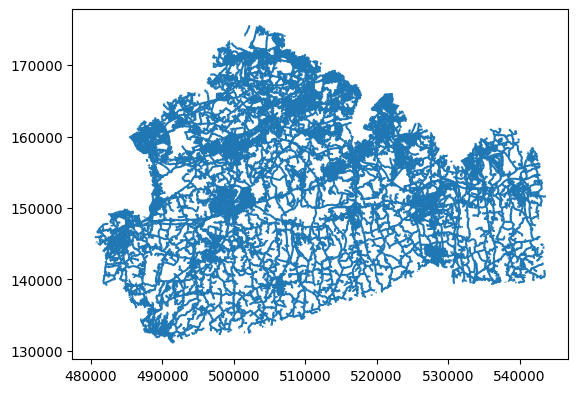

In [ ]:
surrey_roads = roads.clip(surrey_county.geometry)
surrey_roads.plot()

In [ ]:
rivers = read_os_dataset("OpenRivers", "Data/oprvrs_gb.gpkg", 1)
rivers

,id,flow_direction,length,fictitious,form,watercourse_name,watercourse_name_alternative,start_node,end_node,geometry
0,73E1A217-C5BF-41E3-AA17-F969F5181E04,in direction,18.0,0,tidalRiver,None,None,6B77D6D2-B9B2-4FBE-AEA3-8A801079B231,35806C2B-E01E-4CB8-9767-3D6F86302713,"LINESTRING (463513.13 1211952.73, 463524.68 12..."
1,A44E2603-3307-4555-9604-3DAB8AA308C6,in direction,1009.0,0,inlandRiver,None,None,8FA84F8B-71CE-4626-8CEC-5964B94D34CC,D2571525-C2FD-4A2A-8236-7E938081B3E7,"LINESTRING (463559.61 1212995.55, 463604.12 12..."
2,83332CB1-EC9C-486C-AC88-0BE480176548,in direction,1352.0,0,inlandRiver,Burn of Norwick,None,5EEC6ADE-DF7B-4B72-BE47-C78F810C39BF,C3EE6BFE-7B45-4251-951D-4F2A3BB4BBC3,"LINESTRING (463963.5 1214106.5, 463952.5 12140..."
3,83C8021E-C7EF-4C2B-955A-3365D9DDF079,in direction,165.0,0,inlandRiver,None,None,5CF9C9E6-F0D3-4421-81AD-989455DD490C,5EEC6ADE-DF7B-4B72-BE47-C78F810C39BF,"LINESTRING (463993.19 1214238.57, 464010.7 121..."
4,58F9A511-A4BD-47F4-95C1-FE396F677E1B,in direction,27.0,0,inlandRiver,None,None,D2571525-C2FD-4A2A-8236-7E938081B3E7,1740F423-BAF7-4B61-AE72-743CC7BE3D60,"LINESTRING (464188.6 1212433.5, 464188.38 1212..."
...,...,...,...,...,...,...,...,...,...,...
192733,7EB00B29-3123-49FD-AD44-8340BB33F404,in direction,232.0,0,inlandRiver,None,None,04E1EF1B-618C-4BBF-A345-5C783A897E02,5EE99987-0230-4BBB-BDFC-70C96B139C28,"LINESTRING (142067.43 33538.46, 142050.77 3352..."
192734,3355B2D8-576B-430D-BE7D-382B926F0FE7,in direction,732.0,0,inlandRiver,None,None,937C50B0-E3C8-4006-8C05-299E0D3B7334,1FEFFD80-26F0-4BB0-880A-63DE127AD449,"LINESTRING (145424.72 35748.27, 145428.69 3571..."
192735,EE3F229D-62CF-4877-B57F-ADE942804371,in direction,568.0,0,inlandRiver,None,None,03D09FEA-9748-456F-9B92-F0B657624E1C,56037488-0E8B-4A60-8934-7EE1339012EB,"LINESTRING (139378.67 35449.55, 139335.43 3551..."
192736,AC23A1FC-7C84-48AF-9E49-EDD08442AAE1,in direction,733.0,0,inlandRiver,None,None,2F32710C-3CF5-4EEF-B5F8-7D4CFAE7429B,3C77BFD9-D00F-40A5-9D5B-D916B99638CD,"LINESTRING (143070.37 37026.09, 143047.38 3703..."


<Axes: >

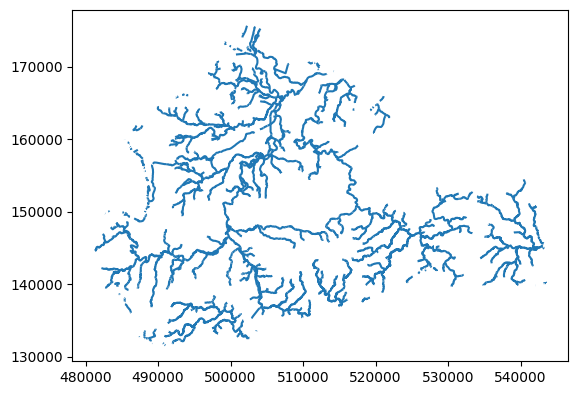

In [ ]:
surrey_rivers = rivers.clip(surrey_county.geometry)
surrey_rivers.plot()

In [ ]:
from io import BytesIO


population_density_request = BytesIO(httpx.get("https://www.ons.gov.uk/file?uri="
    "/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/"
    "lowersuperoutputareapopulationdensity/mid2022revisednov2025tomid2024/sapelsoapopulationdensity20222024.xlsx").read())

pd.read_excel(
    io=population_density_request,
    sheet_name="Mid-2022 to mid-2024 LSOA",
    skiprows=3
)

,LAD 2023 Code,LAD 2023 Name,LSOA 2021 Code,LSOA 2021 Name,Area Sq Km,Mid-2024: Population,Mid-2024: People per Sq Km,Mid-2023: Population,Mid-2023: People per Sq Km,Mid-2022: Population,Mid-2022: People per Sq Km
0,E06000001,Hartlepool,E01011949,Hartlepool 009A,0.5189,1898,3657.737522,1925,3709.770669,1876,3615.340143
1,E06000001,Hartlepool,E01011950,Hartlepool 008A,0.1325,1247,9411.320755,1177,8883.018868,1117,8430.188679
2,E06000001,Hartlepool,E01011951,Hartlepool 007A,0.2086,1393,6677.852349,1320,6327.900288,1260,6040.268456
3,E06000001,Hartlepool,E01011952,Hartlepool 002A,0.4641,1669,3596.207714,1670,3598.362422,1635,3522.947641
4,E06000001,Hartlepool,E01011953,Hartlepool 002B,0.8915,2303,2583.286596,2075,2327.537858,1984,2225.462703
...,...,...,...,...,...,...,...,...,...,...,...
35667,W06000024,Merthyr Tydfil,W01001324,Merthyr Tydfil 003E,3.8037,1848,485.842732,1844,484.791124,1888,496.358809
35668,W06000024,Merthyr Tydfil,W01001898,Merthyr Tydfil 008F,24.6380,1441,58.486890,1437,58.324539,1452,58.933355
35669,W06000024,Merthyr Tydfil,W01001959,Merthyr Tydfil 005E,0.6875,1528,2222.545455,1555,2261.818182,1547,2250.181818
35670,W06000024,Merthyr Tydfil,W01001960,Merthyr Tydfil 005F,0.2485,1453,5847.082495,1467,5903.420523,1481,5959.758551


[Text(0.5, 1.0, 'Surrey Built Up Area Density')]

<Figure size 640x480 with 0 Axes>

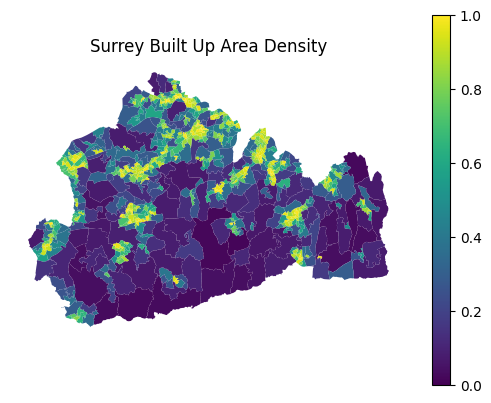

In [ ]:
fig = plt.figure()
ax = surrey_lsoas.plot(
    column="bua_density",
    legend=True,
    norm=Normalize(0,1)
)
ax.set_axis_off()
ax.set(
    title="Surrey Built Up Area Density"
)

[Text(0.5, 1.0, 'Surrey Greenspace Density')]

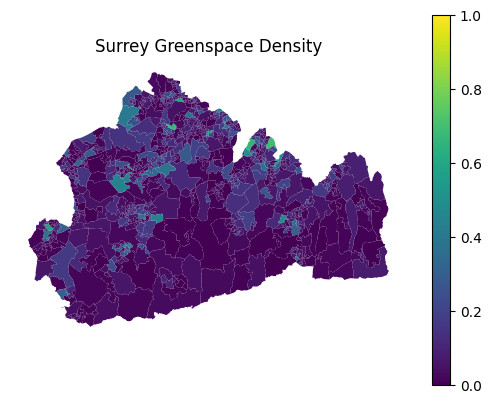

In [ ]:
ax = surrey_lsoas.plot(
    column="greenspace_density",
    legend=True,
    norm=Normalize(0,1)
)
ax.set_axis_off()
ax.set(
    title="Surrey Greenspace Density"
)

[Text(0.5, 1.0, 'Surrey rivers')]

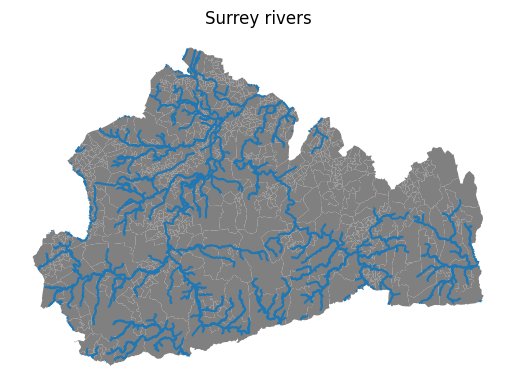

In [ ]:
ax = surrey_rivers.plot()
surrey_lsoas.plot(
    ax=ax,
    color="grey"
)
ax.set_axis_off()
ax.set(
    title="Surrey rivers"
)

[Text(0.5, 1.0, 'Surrey roads')]

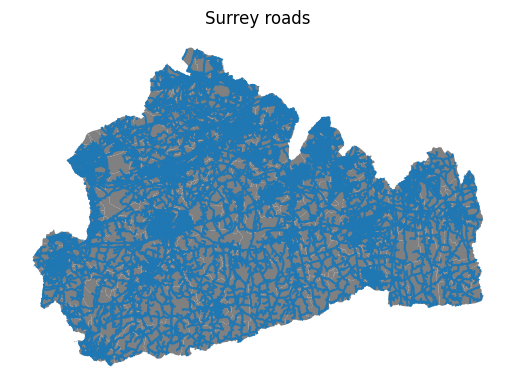

In [ ]:
ax = surrey_roads.plot()
surrey_lsoas.plot(
    ax=ax,
    color="grey"
)
ax.set_axis_off()
ax.set(
    title="Surrey roads"
)